Classification Model Comparison

Machine Learning Capstone Project – 23CSE301

Classification Track – Part A

This notebook implements and compares five supervised machine learning classification algorithms on the assigned dataset.

The classification models covered in this notebook are:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVM)

The models are evaluated using Accuracy, Precision, Recall, Weighted F1-score, Confusion Matrix, and ROC-AUC.

1. Problem Statement

The objective of this project is to develop and compare machine learning classification models for identifying different types of network attacks using network traffic characteristics.

The RT-IoT2022 dataset contains network traffic records with features describing packet statistics, flow characteristics, protocol information, payload behaviour, timing information, and TCP/IP connection properties.

This is formulated as a supervised multi-class classification problem where:

- Input: Network traffic and flow-related features
- Target: Attack_type
- Dataset: RT-IoT2022


2. Dataset Description

The RT-IoT2022 dataset is a network traffic dataset containing records collected from an IoT environment.

Each record represents network traffic described through multiple flow-level and packet-level characteristics. The features include:

- Source and destination port information
- Network protocol and service
- Forward and backward packet statistics
- Packet payload characteristics
- Inter-arrival time (IAT) statistics
- TCP flag counts
- Flow and payload rates
- Active and idle time statistics
- TCP window size information

The dataset contains 123,117 records and 85 columns.

The target variable is `Attack_type`, which represents the class of network activity associated with each traffic record.

The classification task is to learn patterns from the network traffic features and predict the corresponding attack class.

In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

3. Dataset Loading

The RT-IoT2022 dataset is loaded into a Pandas DataFrame for further exploration, preprocessing, and model development.

In [10]:
# Load the dataset

df = pd.read_csv("RT_IOT2022")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [11]:
# Display the first five records

df.head()

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


4. Dataset Overview

Before performing preprocessing and model training, the dataset is examined to understand its dimensions, feature types, missing values, duplicate records, and target-class distribution.

In [12]:
# Display dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names

df.columns.tolist()

# Display data types and non-null information

df.info()

# Statistical summary of numerical features

df.describe()

Number of rows: 123117
Number of columns: 85
<class 'pandas.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  str    
 4   service                   123117 non-null  str    
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ra

,Unnamed: 0,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,1.231170e+05,1.231170e+05,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,123117.000000,123117.000000,123117.000000
mean,37035.089248,34639.258738,1014.305092,3.809566,2.268826,1.909509,1.471218,0.820260,3.518063e+05,3.517620e+05,...,1.481354e+05,2.353599e+04,1.616655e+06,1.701956e+06,3.517644e+06,1.664985e+06,4.550183e+04,6118.905123,2739.776018,751.647514
std,30459.106367,19070.620354,5256.371994,130.005408,22.336565,33.018311,19.635196,32.293948,3.707645e+05,3.708015e+05,...,1.613007e+06,1.477935e+06,8.809396e+06,9.252337e+06,1.229508e+08,9.007064e+06,1.091361e+06,18716.313861,10018.848534,6310.183843
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,6059.000000,17702.000000,21.000000,0.000001,1.000000,1.000000,1.000000,0.000000,7.454354e+01,7.288927e+01,...,9.536740e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
50%,33100.000000,37221.000000,21.000000,0.000004,1.000000,1.000000,1.000000,0.000000,2.467238e+05,2.467238e+05,...,4.053116e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
75%,63879.000000,50971.000000,21.000000,0.000005,1.000000,1.000000,1.000000,0.000000,5.242880e+05,5.242880e+05,...,5.006790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
max,94658.000000,65535.000000,65389.000000,21728.335578,4345.000000,10112.000000,4345.000000,10105.000000,1.048576e+06,1.048576e+06,...,4.374931e+08,4.774862e+08,3.000000e+08,3.000000e+08,2.096777e+10,3.000000e+08,1.208029e+08,65535.000000,65535.000000,65535.000000


4.1 Missing Value Analysis

Missing values are checked to determine whether any feature requires imputation or other data-cleaning treatment before model training.

In [13]:
# Check missing values

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

4.2 Duplicate Record Analysis

Duplicate records are checked because repeated observations may affect the model's learning process and evaluation.

In [14]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [15]:
# Remove duplicate records if present

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (123117, 85)


4.3 Target Variable Analysis

The target variable `Attack_type` represents the different categories of network activity present in the RT-IoT2022 dataset.

The distribution of the target classes is examined to understand the number of observations belonging to each class and to identify any class imbalance that may affect classification model performance.

In [16]:
# Display the distribution of attack types

attack_counts = df["Attack_type"].value_counts()

attack_counts

Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

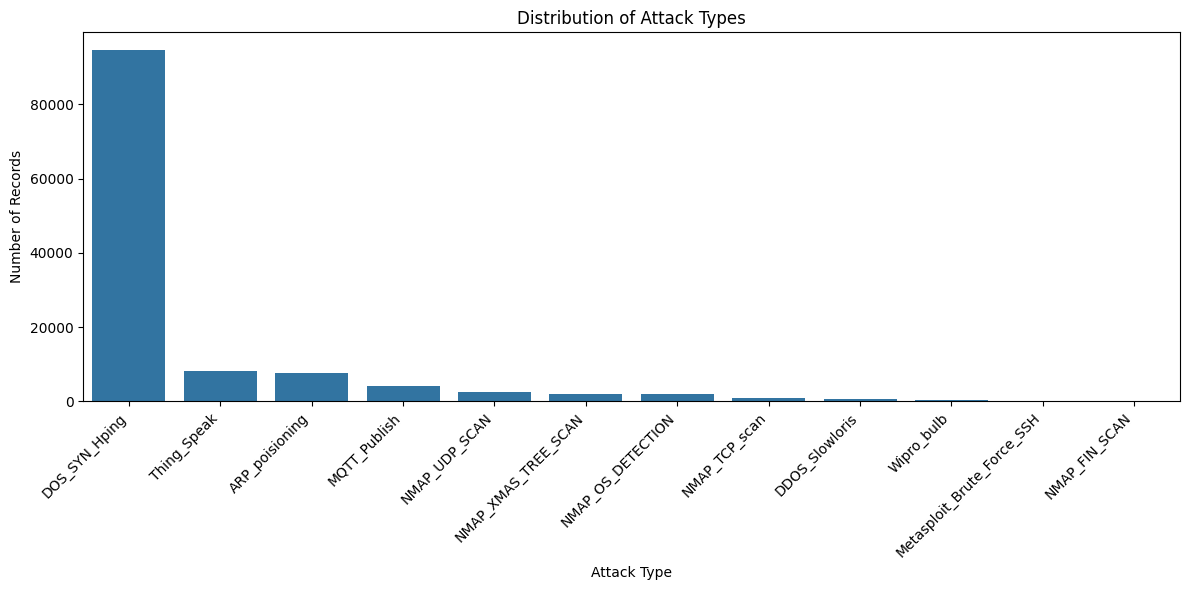

In [17]:
# Visualize the distribution of attack types

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Attack_type",
    order=df["Attack_type"].value_counts().index
)

plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

The target variable shows a highly imbalanced class distribution. The `DoS_SYN_Hping` class contains substantially more observations than the other attack categories, while several classes contain comparatively fewer records.

This class imbalance should be considered during model evaluation because overall accuracy alone may not adequately represent the performance of a classifier across all attack categories. Therefore, Precision, Recall, Weighted F1-score, Confusion Matrix, and ROC-AUC are also considered for model evaluation.

5. Feature Analysis

The dataset contains multiple network traffic features describing packet behaviour, flow characteristics, protocol information, timing statistics, and other network-level properties.

The feature types are examined to determine which variables are numerical and which are categorical before preprocessing.

In [18]:
# Identify numerical and categorical features

numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 82
Number of categorical features: 3

Categorical features:
['proto', 'service', 'Attack_type']


In [19]:
# Display numerical features

print("Numerical features:")
print(numerical_features)

Numerical features:
['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.to

6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution, relationships, and characteristics of the network traffic features.

The analysis includes:

- Distribution of numerical features
- Correlation analysis
- Feature-target relationships
- Target class distribution
- Identification of potentially important patterns and unusual observations

6.1 Distribution of Numerical Features

The distributions of the numerical features are examined to understand their range, spread, skewness, and potential presence of unusual observations.

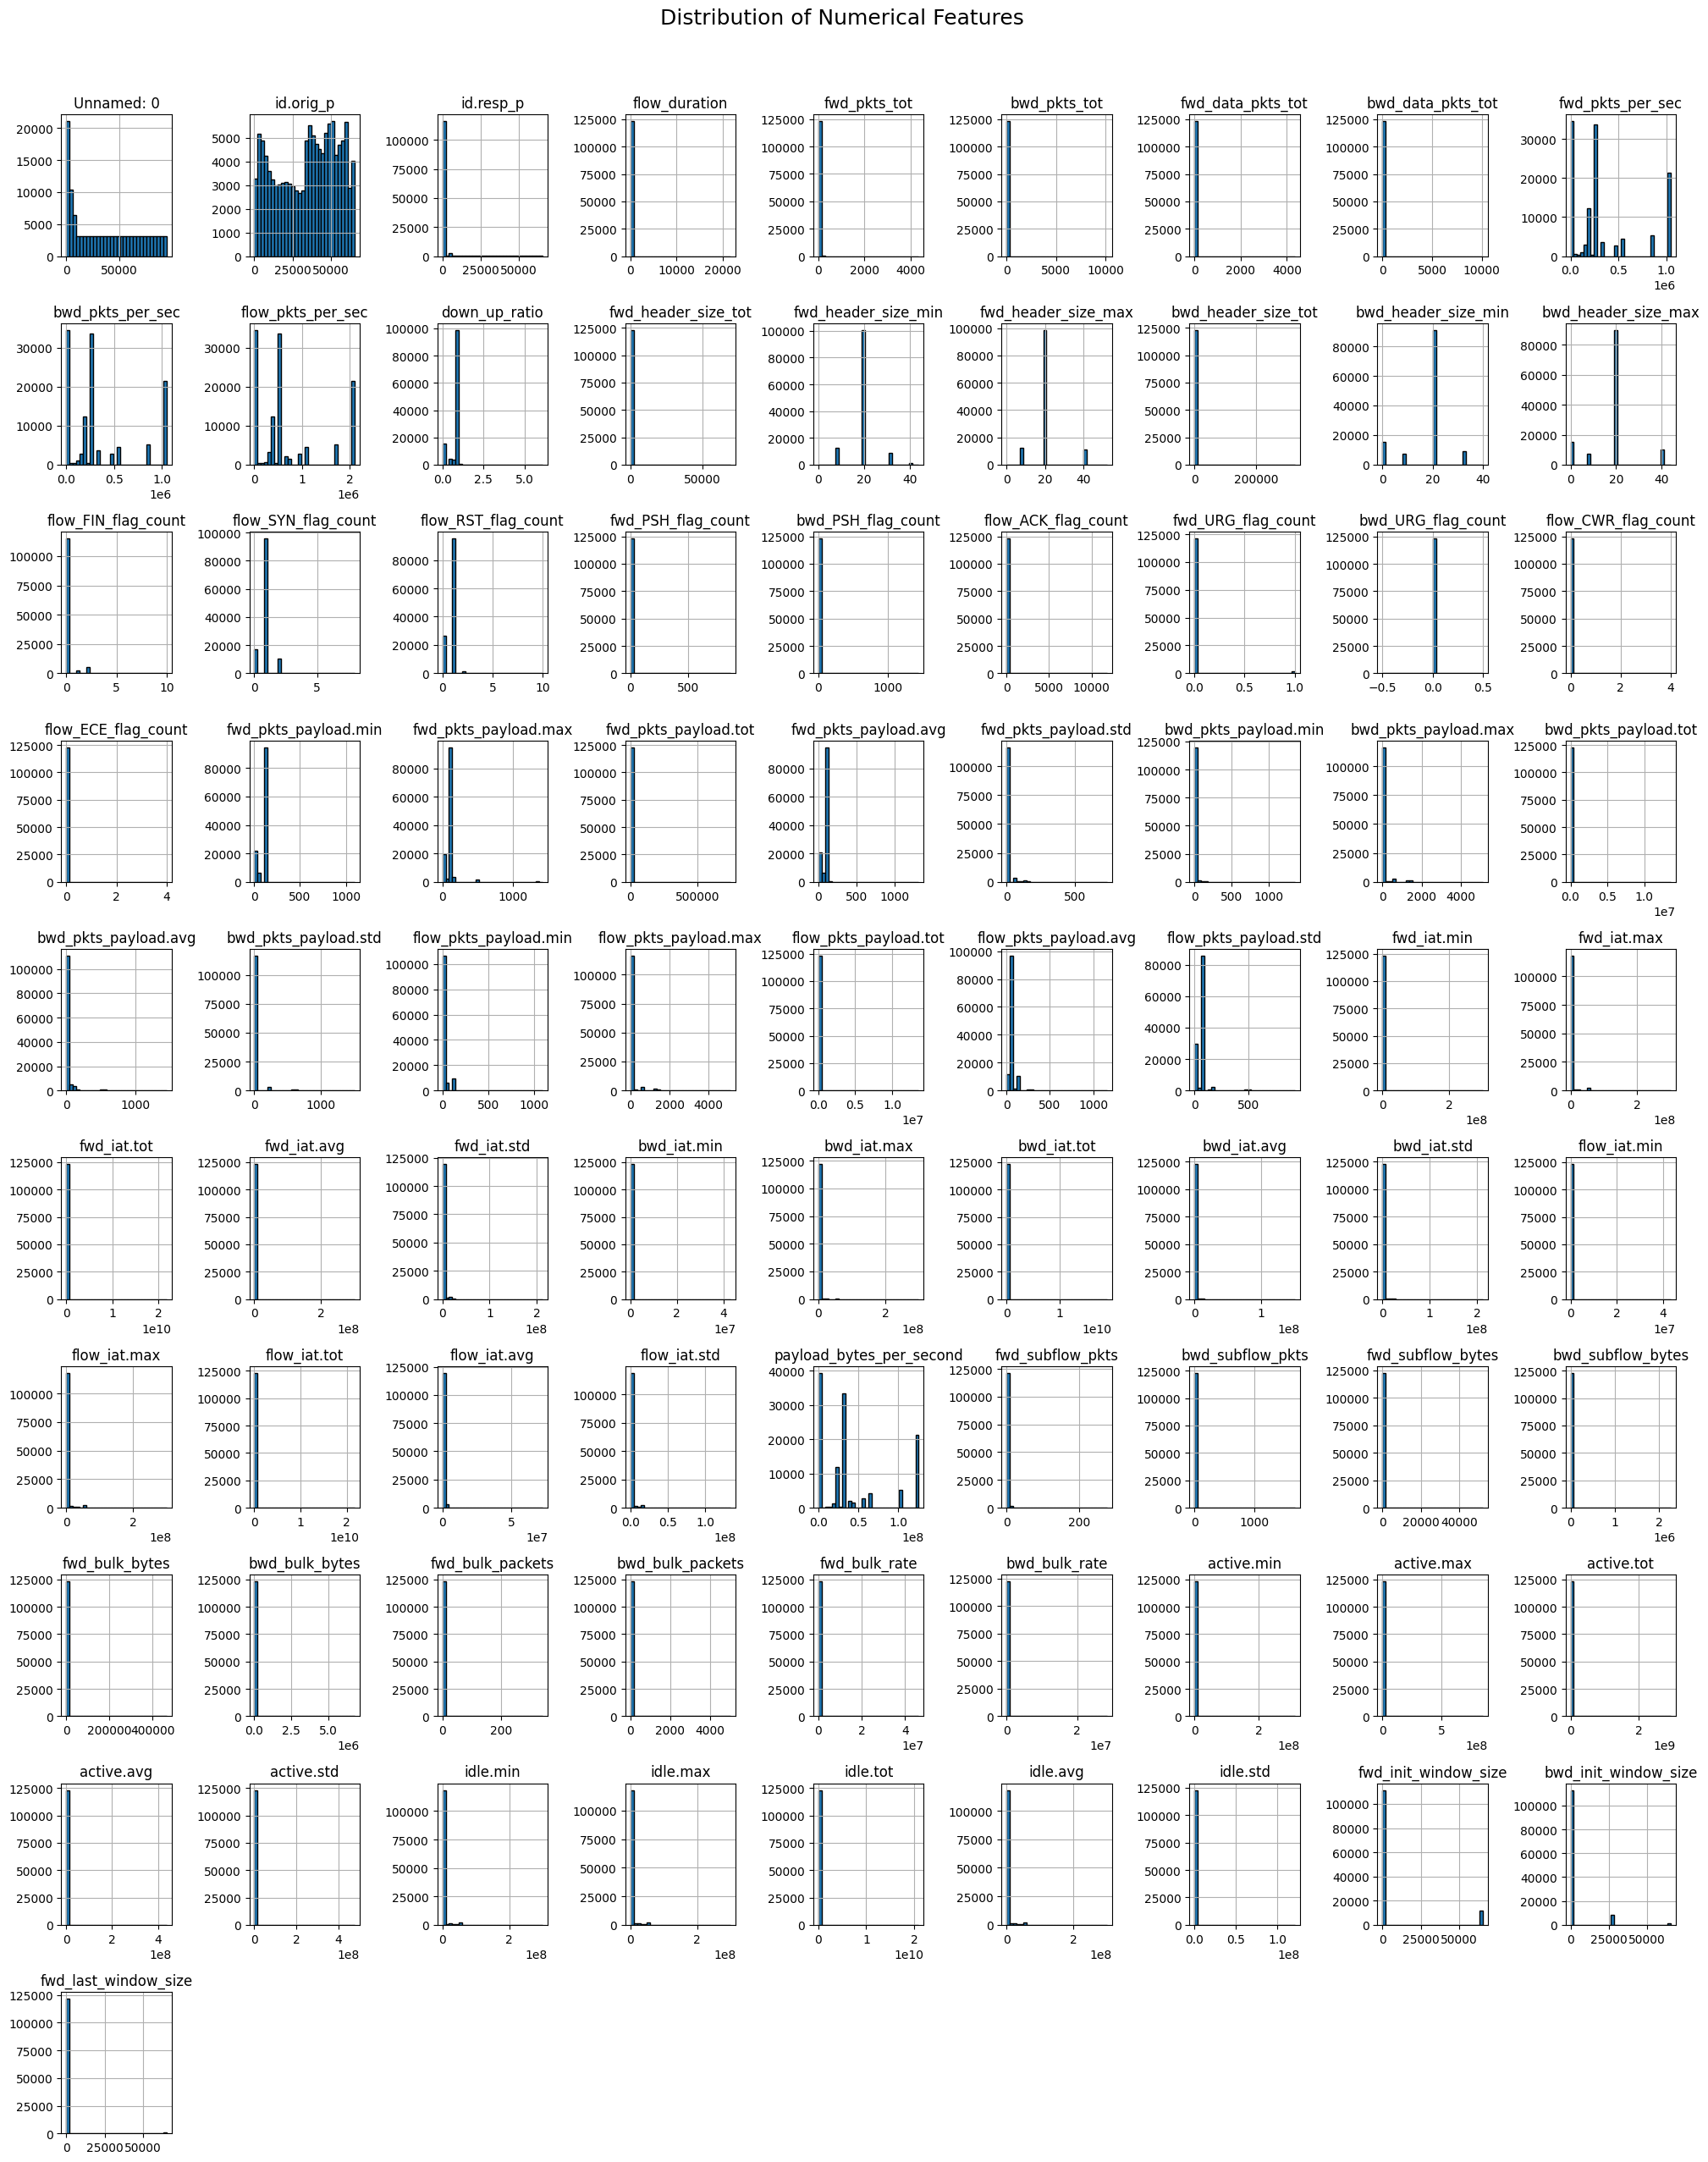

In [20]:
# Plot distributions of numerical features

df[numerical_features].hist(
    figsize=(20, 25),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

6.2 Correlation Analysis

A correlation heatmap is used to examine the relationships between numerical features.

Strong correlations between features may indicate redundancy or similar information, while correlations with other variables can provide useful insights into the structure of the dataset.

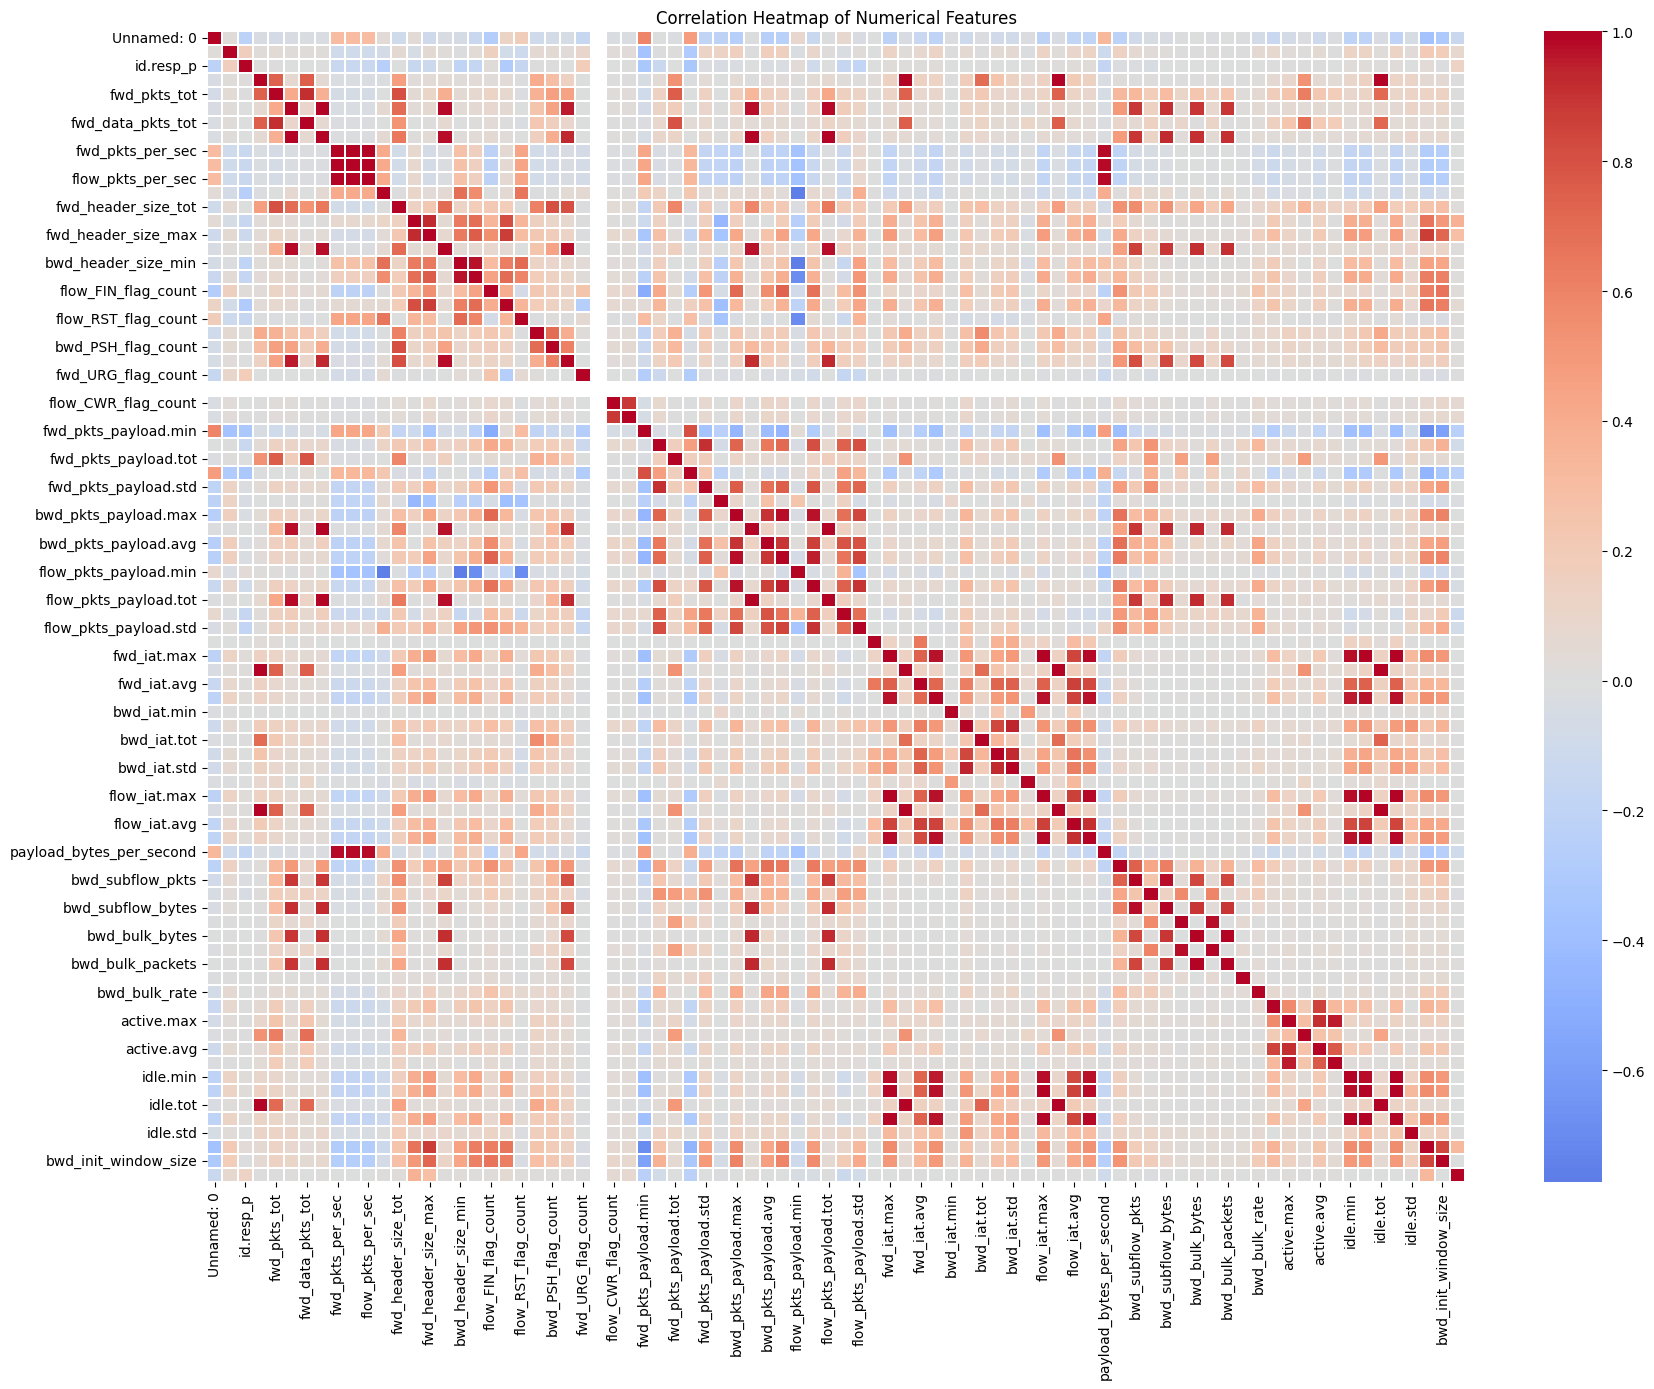

In [21]:
# Compute correlation matrix

correlation_matrix = df[numerical_features].corr()

# Plot correlation heatmap

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

6.3 Feature-Target Relationships

The relationship between selected numerical network traffic features and the target variable `Attack_type` is examined using scatter plots.

Since `Attack_type` is a categorical variable, its classes are temporarily encoded for visualization purposes only. The encoded values represent different classes and do not imply an ordinal relationship between attack categories.

In [22]:
# Temporarily encode attack types for visualization

attack_type_codes = pd.Categorical(df["Attack_type"]).codes

df["Attack_type_code"] = attack_type_codes

df[["Attack_type", "Attack_type_code"]].head()

,Attack_type,Attack_type_code
0,MQTT_Publish,3
1,MQTT_Publish,3
2,MQTT_Publish,3
3,MQTT_Publish,3
4,MQTT_Publish,3


In [23]:
# Display the numerical features for selecting variables for EDA

for i, feature in enumerate(numerical_features, start=1):
    print(f"{i}. {feature}")

1. Unnamed: 0
2. id.orig_p
3. id.resp_p
4. flow_duration
5. fwd_pkts_tot
6. bwd_pkts_tot
7. fwd_data_pkts_tot
8. bwd_data_pkts_tot
9. fwd_pkts_per_sec
10. bwd_pkts_per_sec
11. flow_pkts_per_sec
12. down_up_ratio
13. fwd_header_size_tot
14. fwd_header_size_min
15. fwd_header_size_max
16. bwd_header_size_tot
17. bwd_header_size_min
18. bwd_header_size_max
19. flow_FIN_flag_count
20. flow_SYN_flag_count
21. flow_RST_flag_count
22. fwd_PSH_flag_count
23. bwd_PSH_flag_count
24. flow_ACK_flag_count
25. fwd_URG_flag_count
26. bwd_URG_flag_count
27. flow_CWR_flag_count
28. flow_ECE_flag_count
29. fwd_pkts_payload.min
30. fwd_pkts_payload.max
31. fwd_pkts_payload.tot
32. fwd_pkts_payload.avg
33. fwd_pkts_payload.std
34. bwd_pkts_payload.min
35. bwd_pkts_payload.max
36. bwd_pkts_payload.tot
37. bwd_pkts_payload.avg
38. bwd_pkts_payload.std
39. flow_pkts_payload.min
40. flow_pkts_payload.max
41. flow_pkts_payload.tot
42. flow_pkts_payload.avg
43. flow_pkts_payload.std
44. fwd_iat.min
45. fwd_iat.

6.4 Feature-Target Relationship: Flow Duration

The relationship between `flow_duration` and the target attack category is visualized to examine whether differences in flow duration are associated with different types of network activity.

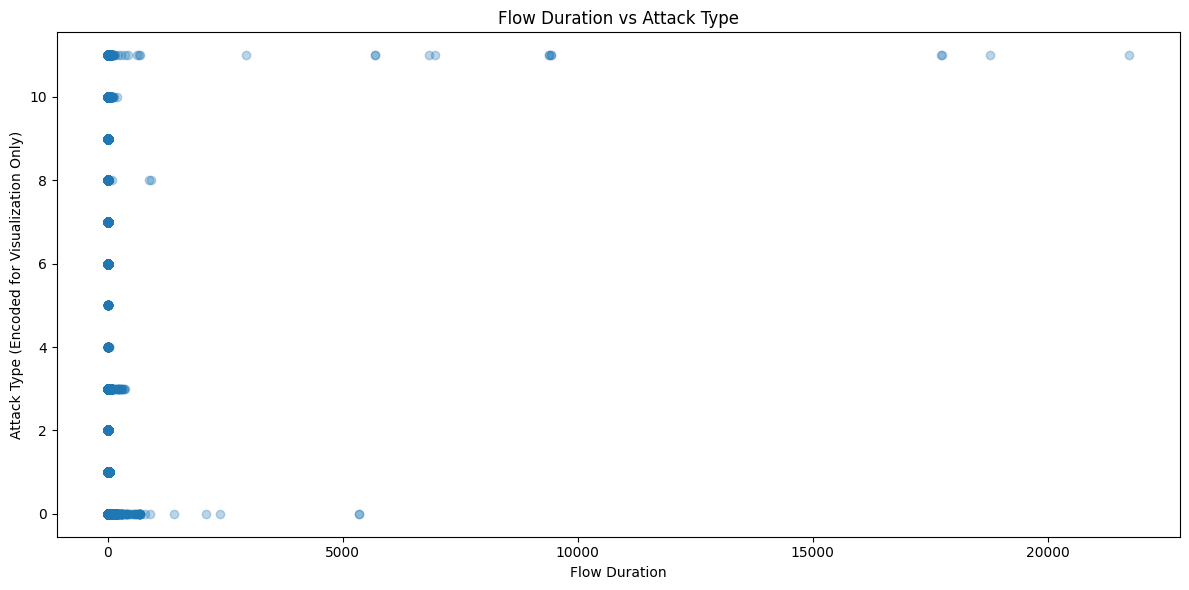

In [24]:
# Scatter plot: Flow Duration vs Attack Type

plt.figure(figsize=(12, 6))

plt.scatter(
    df["flow_duration"],
    df["Attack_type_code"],
    alpha=0.3
)

plt.title("Flow Duration vs Attack Type")
plt.xlabel("Flow Duration")
plt.ylabel("Attack Type (Encoded for Visualization Only)")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows that most network traffic records have relatively low flow durations, while a smaller number of observations have considerably larger flow durations. The values are spread across multiple attack categories, indicating that flow duration alone does not clearly separate the different attack types. Some extreme flow-duration values are also visible and should be considered during outlier analysis.

6.5 Feature-Target Relationship: Forward Packet Count

The relationship between `fwd_pkts_tot` and the target attack category is visualized to examine whether the number of forward packets varies across different attack classes.

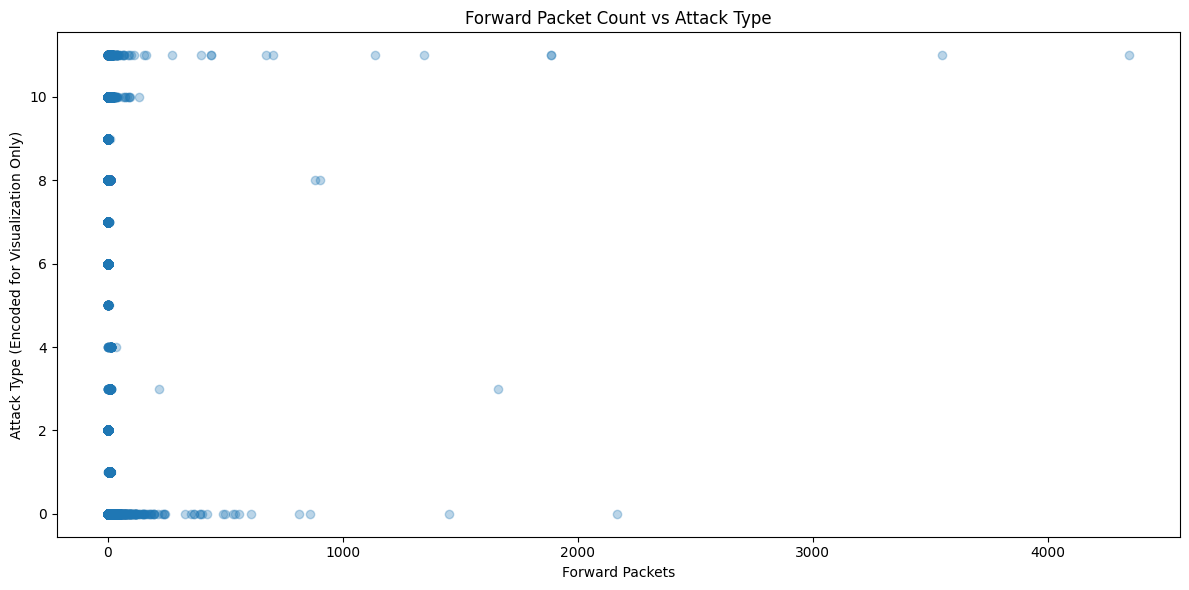

In [25]:
# Scatter plot: Forward Packets vs Attack Type

plt.figure(figsize=(12, 6))

plt.scatter(
    df["fwd_pkts_tot"],
    df["Attack_type_code"],
    alpha=0.3
)

plt.title("Forward Packet Count vs Attack Type")
plt.xlabel("Forward Packets")
plt.ylabel("Attack Type (Encoded for Visualization Only)")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows that most observations have relatively low forward packet counts, while a smaller number of records have substantially higher values. The feature values occur across multiple attack categories, suggesting that forward packet count alone may not be sufficient to distinguish all attack types. The presence of high-valued observations will also be considered during subsequent outlier analysis.

7. Categorical Feature Analysis

The categorical input features are analysed to understand the number of unique categories and their distributions. This analysis helps determine the appropriate encoding strategy before model training.

7.1 Protocol Distribution

The `proto` feature represents the network protocol associated with each traffic record. Its category distribution is examined to identify the protocols present in the dataset.

In [26]:
# Display protocol distribution

proto_counts = df["proto"].value_counts()

print("Number of unique protocols:", df["proto"].nunique())
proto_counts

Number of unique protocols: 3


proto
tcp     110427
udp      12633
icmp        57
Name: count, dtype: int64

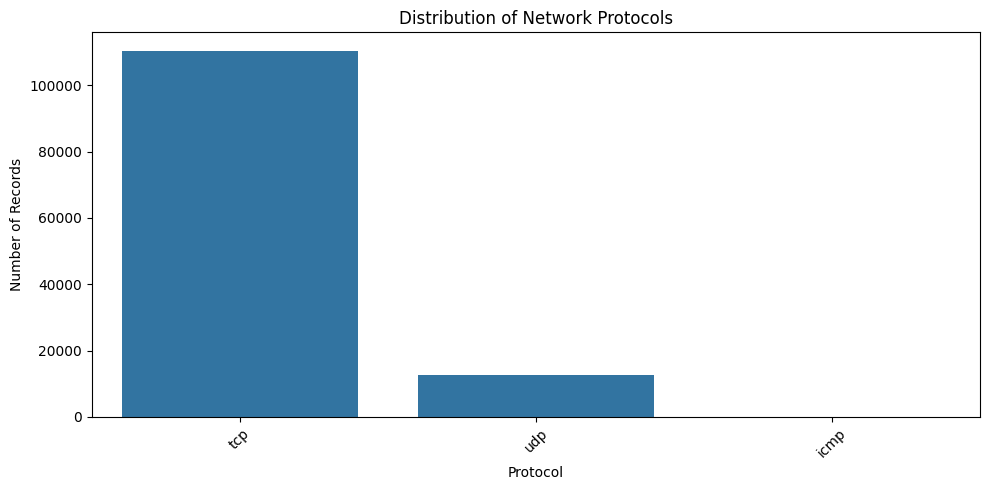

In [27]:
# Visualize protocol distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="proto",
    order=df["proto"].value_counts().index
)

plt.title("Distribution of Network Protocols")
plt.xlabel("Protocol")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The protocol distribution is highly imbalanced, with TCP accounting for the majority of network traffic records. UDP represents a substantially smaller portion of the dataset, while ICMP occurs only in a small number of records.

This indicates that the `proto` feature is dominated by TCP traffic, although the less frequent protocol categories may still provide useful information for distinguishing certain attack types.

7.2 Service Distribution

The `service` feature represents the network service associated with the traffic record. Its distribution is examined to understand the categorical values present in the dataset.

In [28]:
# Display service distribution

service_counts = df["service"].value_counts()

print("Number of unique services:", df["service"].nunique())
service_counts

Number of unique services: 10


service
-         102861
dns         9753
mqtt        4132
http        3464
ssl         2663
ntp          121
dhcp          50
irc           43
ssh           28
radius         2
Name: count, dtype: int64

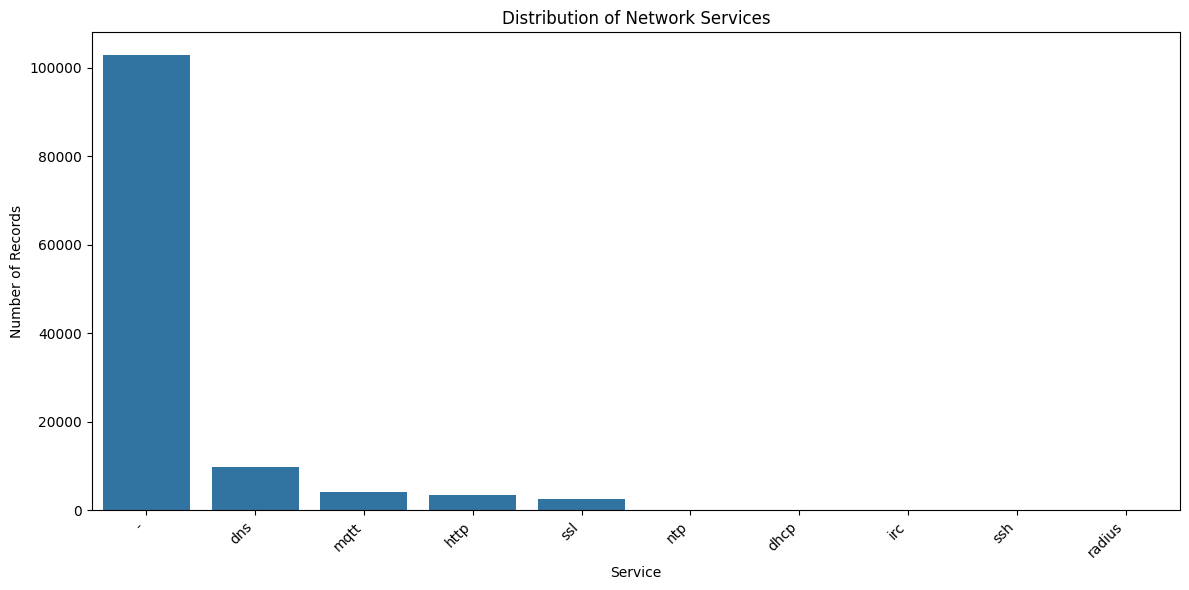

In [29]:
# Visualize service distribution

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="service",
    order=df["service"].value_counts().index
)

plt.title("Distribution of Network Services")
plt.xlabel("Service")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

The service distribution is also highly uneven. The `-` category represents the largest number of records, followed by services such as DNS, MQTT, HTTP, and SSL. Several services occur only in a small number of observations.

The variation in service frequencies indicates that the `service` feature contains both common and relatively rare categories, which will be considered when selecting an appropriate encoding strategy during preprocessing.

8. Data Preprocessing

The preprocessing stage prepares the dataset for classification model training. It includes inspecting potential index columns, checking numerical features for outliers, creating a meaningful engineered feature, encoding categorical variables, separating the target variable, splitting the data into training and testing sets, and applying feature scaling where required.

8.1 Inspection of the Index Column

The `Unnamed: 0` feature is inspected to determine whether it represents meaningful network information or simply acts as a row/index identifier. An index-like feature should not be used as a predictive variable because it does not represent an actual characteristic of the network traffic.

In [30]:
# Inspect the Unnamed: 0 column

print("First 10 values:")
print(df["Unnamed: 0"].head(10))

print("\nNumber of unique values:")
print(df["Unnamed: 0"].nunique())

print("\nNumber of rows:")
print(len(df))

print("\nMinimum value:", df["Unnamed: 0"].min())
print("Maximum value:", df["Unnamed: 0"].max())

First 10 values:
0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: Unnamed: 0, dtype: int64

Number of unique values:
94659

Number of rows:
123117

Minimum value: 0
Maximum value: 94658


In [31]:
# Check whether Unnamed: 0 behaves like an index

is_index_like = (
    df["Unnamed: 0"].reset_index(drop=True)
    .equals(pd.Series(range(len(df))))
)

print("Is Unnamed: 0 a sequential index?:", is_index_like)

Is Unnamed: 0 a sequential index?: False


In [32]:
# Check repeated values in Unnamed: 0

index_value_counts = df["Unnamed: 0"].value_counts()

print("Number of values appearing more than once:",
      (index_value_counts > 1).sum())

print("\nMost frequent values:")
print(index_value_counts.head(10))

Number of values appearing more than once: 8108

Most frequent values:
Unnamed: 0
0    12
1    12
2    12
3    12
4    12
5    12
6    12
7    12
8    12
9    12
Name: count, dtype: int64


In [33]:
# Check whether Unnamed: 0 has a meaningful relationship with the target

print(
    df.groupby("Attack_type")["Unnamed: 0"]
      .agg(["min", "max", "nunique"])
)

                            min    max  nunique
Attack_type                                    
ARP_poisioning                0   7749     7750
DDOS_Slowloris                0    533      534
DOS_SYN_Hping                 0  94658    94659
MQTT_Publish                  0   4145     4146
Metasploit_Brute_Force_SSH    0     36       37
NMAP_FIN_SCAN                 0     27       28
NMAP_OS_DETECTION             0   1999     2000
NMAP_TCP_scan                 0   1001     1002
NMAP_UDP_SCAN                 0   2589     2590
NMAP_XMAS_TREE_SCAN           0   2009     2010
Thing_Speak                   0   8107     8108
Wipro_bulb                    0    252      253


8.2 Outlier Analysis

Outlier analysis is performed on the numerical features to identify observations with unusually high or low values.

For network traffic data, extreme values may represent genuine traffic behaviour or attack characteristics rather than errors. Therefore, the presence of outliers is examined before deciding whether any treatment is necessary.

In [34]:
# Calculate the number of outliers using the IQR method

Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)

IQR = Q3 - Q1

outlier_counts = (
    ((df[numerical_features] < (Q1 - 1.5 * IQR)) |
     (df[numerical_features] > (Q3 + 1.5 * IQR)))
    .sum()
)

outlier_summary = (
    outlier_counts
    .sort_values(ascending=False)
    .to_frame("Outlier Count")
)

outlier_summary.head(15)

,Outlier Count
flow_pkts_payload.avg,38116
bwd_header_size_tot,33148
bwd_header_size_max,33137
flow_ACK_flag_count,33083
bwd_pkts_tot,32364
bwd_subflow_pkts,32343
bwd_header_size_min,32065
fwd_pkts_payload.min,28458
fwd_last_window_size,28458
fwd_pkts_payload.max,28458


### Observation

The IQR analysis indicates the presence of a substantial number of statistical outliers in several numerical network traffic features. Features such as `flow_pkts_payload.avg`, `bwd_header_size_tot`, `bwd_header_size_max`, and `flow_ACK_flag_count` contain relatively large numbers of observations outside the IQR-based boundaries.

These extreme values are not automatically treated as errors because they may represent legitimate variations in network traffic or attack behaviour. Therefore, the observations are retained rather than removed. Feature scaling and model-specific preprocessing will be used where appropriate.

8.3 Removal of Temporary Visualization Feature

The `Attack_type_code` column was created only for visualizing the categorical target variable in the scatter plots. Since it is an artificial representation of the target and is not an original dataset feature, it is removed before model development to prevent target leakage.

In [35]:
# Remove the temporary visualization column

df = df.drop(columns=["Attack_type_code"])

print("Attack_type_code present:", "Attack_type_code" in df.columns)

Attack_type_code present: False


8.4 Feature Engineering

A forward-to-backward packet ratio is created as an additional network traffic feature.

This feature represents the relative amount of forward traffic compared with backward traffic. It provides an additional measure of traffic directionality that may help the classification models distinguish different network behaviours.

A value of 1 is added to the denominator to avoid division by zero when no backward packets are present.

In [36]:
# Create a forward-to-backward packet ratio

df["fwd_bwd_pkt_ratio"] = (
    df["fwd_pkts_tot"] / (df["bwd_pkts_tot"] + 1)
)

print("New feature created: fwd_bwd_pkt_ratio")

df[["fwd_pkts_tot", "bwd_pkts_tot", "fwd_bwd_pkt_ratio"]].head()

New feature created: fwd_bwd_pkt_ratio


,fwd_pkts_tot,bwd_pkts_tot,fwd_bwd_pkt_ratio
0,9,5,1.5
1,9,5,1.5
2,9,5,1.5
3,9,5,1.5
4,9,5,1.5


In [37]:
# Check the engineered feature

print("Minimum ratio:", df["fwd_bwd_pkt_ratio"].min())
print("Maximum ratio:", df["fwd_bwd_pkt_ratio"].max())
print("Mean ratio:", df["fwd_bwd_pkt_ratio"].mean())

Minimum ratio: 0.0
Maximum ratio: 4345.0
Mean ratio: 0.7859406061066669


8.5 Categorical Feature Encoding

The dataset contains two categorical input features, `proto` and `service`. Since these are nominal categories without an inherent numerical ordering, One-Hot Encoding is used to convert them into numerical representations suitable for classification algorithms.

The target variable, `Attack_type`, contains multiple attack categories and will be encoded separately as class labels.

In [38]:
# Identify categorical input features

categorical_features = ["proto", "service"]

print("Categorical input features:")
print(categorical_features)

print("\nNumber of categories:")
for feature in categorical_features:
    print(feature, ":", df[feature].nunique())

Categorical input features:
['proto', 'service']

Number of categories:
proto : 3
service : 10


In [39]:
# Display categories in categorical features

for feature in categorical_features:
    print(f"\n{feature} categories:")
    print(df[feature].unique())


proto categories:
<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

service categories:
<StringArray>
['mqtt', '-', 'http', 'dns', 'ntp', 'ssl', 'dhcp', 'irc', 'ssh', 'radius']
Length: 10, dtype: str


#### Encoding the Target Variable

The `Attack_type` column represents the target variable containing multiple network attack categories. Label Encoding is applied to convert each attack category into a numerical class label required by the classification algorithms.

In [40]:
from sklearn.preprocessing import LabelEncoder

# Encode the target variable

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["Attack_type"])

print("Attack classes:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, ":", class_name)

print("\nNumber of classes:", len(label_encoder.classes_))

Attack classes:
0 : ARP_poisioning
1 : DDOS_Slowloris
2 : DOS_SYN_Hping
3 : MQTT_Publish
4 : Metasploit_Brute_Force_SSH
5 : NMAP_FIN_SCAN
6 : NMAP_OS_DETECTION
7 : NMAP_TCP_scan
8 : NMAP_UDP_SCAN
9 : NMAP_XMAS_TREE_SCAN
10 : Thing_Speak
11 : Wipro_bulb

Number of classes: 12


8.6 Separating Features and Target

The target variable `Attack_type` is separated from the input features. The input matrix `X` contains the network traffic features, while `y` contains the encoded attack classes.

The target variable is excluded from the input features to prevent target leakage during model training.

In [41]:
# Separate input features and target variable

X = df.drop(columns=["Attack_type"])
y = label_encoder.transform(df["Attack_type"])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (123117, 85)
Target vector shape: (123117,)


8.7 One-Hot Encoding of Categorical Features

The categorical input features `proto` and `service` are converted into numerical form using One-Hot Encoding.

One-Hot Encoding creates a separate binary feature for each category without imposing an artificial numerical ordering between categories.

In [42]:
from sklearn.preprocessing import OneHotEncoder

# Create One-Hot Encoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Encode categorical features

X_categorical = encoder.fit_transform(
    X[["proto", "service"]]
)

print("Encoded categorical feature shape:", X_categorical.shape)

Encoded categorical feature shape: (123117, 13)


8.6.1 Final Feature Preparation

The non-predictive identifier `Unnamed: 0` is removed from the dataset before model development. The target variable `Attack_type` is kept separately as the prediction target.

The categorical input features `proto` and `service` will be encoded after the train-test split so that the preprocessing is derived from the training data.

In [43]:
# Remove the non-predictive identifier

df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape after removing identifier:", df.shape)

Dataset shape after removing identifier: (123117, 85)


8.7 Final Separation of Features and Target

The input features are separated from the target variable `Attack_type`. The categorical input features remain in `X` temporarily and will be encoded after the train-test split.

In [44]:
# Separate features and target

X = df.drop(columns=["Attack_type"])
y = label_encoder.transform(df["Attack_type"])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (123117, 84)
Target vector shape: (123117,)


8.8 Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split.

The training set is used to learn the classification models, while the testing set is kept separate for evaluating their performance on unseen data.

Stratification is applied to preserve the distribution of the different attack classes in both subsets.

In [45]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (98493, 84)
Testing feature shape: (24624, 84)
Training target shape: (98493,)
Testing target shape: (24624,)


8.9 One-Hot Encoding of Categorical Features

The categorical features `proto` and `service` are one-hot encoded after splitting the data.

The encoder is fitted using only the training data and then applied to both the training and testing sets. This ensures that information from the test set is not used during preprocessing.

In [46]:
from sklearn.preprocessing import OneHotEncoder

# Create the encoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit only on training categorical features

X_train_cat = encoder.fit_transform(
    X_train[["proto", "service"]]
)

# Transform test categorical features

X_test_cat = encoder.transform(
    X_test[["proto", "service"]]
)

print("Encoded training categorical shape:", X_train_cat.shape)
print("Encoded testing categorical shape:", X_test_cat.shape)

Encoded training categorical shape: (98493, 13)
Encoded testing categorical shape: (24624, 13)


8.10 Construction of Final Feature Matrix

The numerical features and the one-hot encoded categorical features are combined to create the final feature matrices used for model training and testing.

The same feature representation is maintained for both the training and testing datasets.

In [47]:
# Separate numerical features from categorical features

numerical_features_final = [
    col for col in X_train.columns
    if col not in ["proto", "service"]
]

X_train_num = X_train[numerical_features_final]
X_test_num = X_test[numerical_features_final]

print("Numerical training shape:", X_train_num.shape)
print("Numerical testing shape:", X_test_num.shape)

Numerical training shape: (98493, 82)
Numerical testing shape: (24624, 82)


In [48]:
# Combine numerical and encoded categorical features

X_train_final = np.hstack([
    X_train_num.values,
    X_train_cat
])

X_test_final = np.hstack([
    X_test_num.values,
    X_test_cat
])

print("Final training feature shape:", X_train_final.shape)
print("Final testing feature shape:", X_test_final.shape)

Final training feature shape: (98493, 95)
Final testing feature shape: (24624, 95)


8.11 Feature Scaling

Feature scaling is applied to the numerical feature matrix so that features with different numerical ranges contribute appropriately to distance-based and optimization-based classification algorithms.

Standardization is performed using `StandardScaler`, which transforms the features to have approximately zero mean and unit variance.

The scaler is fitted only on the training data and then applied to the testing data to prevent information leakage.

In [49]:
# Apply Standard Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (98493, 95)
Scaled testing shape: (24624, 95)


9. Classification Models

Five classification algorithms are implemented and evaluated for multi-class network attack classification.

The models are trained using the preprocessed training data and evaluated on the unseen testing data. Accuracy, precision, recall, F1-score, and confusion matrices are used to assess classification performance.

9.1 Logistic Regression

Logistic Regression is used as a baseline classification model for predicting the attack category. Although Logistic Regression is commonly used for binary classification, its multiclass extension allows it to classify observations into multiple attack categories.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model

logistic_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_lr = logistic_model.predict(X_test_scaled)

# Calculate evaluation metrics

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average="weighted", zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, average="weighted", zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted", zero_division=0)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.992040285899935
Precision: 0.9919873632714824
Recall   : 0.992040285899935
F1-Score : 0.9919230868907707


In [51]:
from sklearn.metrics import classification_report

print("Classification Report - Logistic Regression")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))

Classification Report - Logistic Regression
                            precision    recall  f1-score   support

            ARP_poisioning       0.95      0.95      0.95      1550
            DDOS_Slowloris       0.96      0.80      0.87       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       1.00      0.86      0.92         7
             NMAP_FIN_SCAN       0.83      0.83      0.83         6
         NMAP_OS_DETECTION       0.99      1.00      1.00       400
             NMAP_TCP_scan       1.00      1.00      1.00       200
             NMAP_UDP_SCAN       0.96      0.98      0.97       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.95      0.96      0.96      1622
                Wipro_bulb       0.86      0.59      0.70        51

                  accuracy                           0.99     24624
  

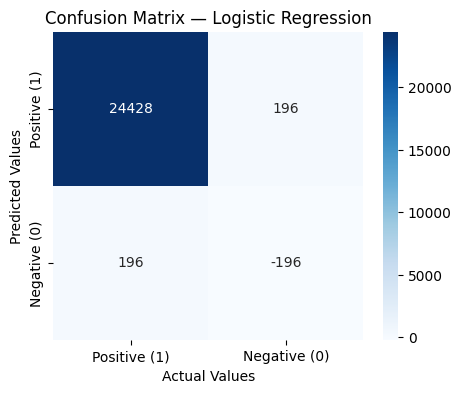

In [87]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Logistic Regression predictions
cm = confusion_matrix(y_test, y_pred_lr)

# Calculate overall TP, FP, FN, TN
TP = np.trace(cm)
FP = cm.sum(axis=0).sum() - np.trace(cm)
FN = cm.sum(axis=1).sum() - np.trace(cm)
TN = cm.sum() - TP - FP - FN

# Create 2x2 confusion matrix
cm_lr = np.array([
    [TP, FP],
    [FN, TN]
])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Positive (1)', 'Negative (0)'],
    yticklabels=['Positive (1)', 'Negative (0)']
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

9.2 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a distance-based classification algorithm that assigns a class to an observation based on the classes of its nearest neighboring observations.

Since KNN relies on distance calculations, the standardized feature matrix is used for training and prediction.

In [54]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model

knn_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate evaluation metrics

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(
    y_test, y_pred_knn,
    average="weighted",
    zero_division=0
)
knn_recall = recall_score(
    y_test, y_pred_knn,
    average="weighted",
    zero_division=0
)
knn_f1 = f1_score(
    y_test, y_pred_knn,
    average="weighted",
    zero_division=0
)

print("KNN Results")
print("-----------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1-Score :", knn_f1)

KNN Results
-----------
Accuracy : 0.9965074723846654
Precision: 0.9965127850439786
Recall   : 0.9965074723846654
F1-Score : 0.9964973830510698


In [55]:
print("Classification Report - KNN")

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - KNN
                            precision    recall  f1-score   support

            ARP_poisioning       0.97      0.98      0.98      1550
            DDOS_Slowloris       0.96      0.95      0.96       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       1.00      0.86      0.92         7
             NMAP_FIN_SCAN       0.83      0.83      0.83         6
         NMAP_OS_DETECTION       0.99      1.00      1.00       400
             NMAP_TCP_scan       1.00      1.00      1.00       200
             NMAP_UDP_SCAN       0.99      0.99      0.99       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.99      0.98      0.98      1622
                Wipro_bulb       0.96      0.84      0.90        51

                  accuracy                           1.00     24624
                 m

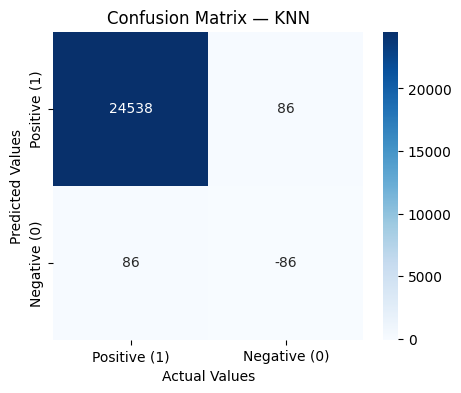

In [88]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# KNN predictions
cm = confusion_matrix(y_test, y_pred_knn)

# Calculate overall TP, FP, FN, TN
TP = np.trace(cm)
FP = cm.sum(axis=0).sum() - TP
FN = cm.sum(axis=1).sum() - TP
TN = cm.sum() - TP - FP - FN

# Create 2x2 confusion matrix
cm_knn = np.array([
    [TP, FP],
    [FN, TN]
])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Positive (1)', 'Negative (0)'],
    yticklabels=['Positive (1)', 'Negative (0)']
)

plt.title("Confusion Matrix — KNN")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

9.3 Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. It assumes that the numerical features follow a Gaussian distribution within each class and that the features are conditionally independent given the class.

The model is trained on the preprocessed feature matrix and evaluated on the unseen test data.

In [58]:
from sklearn.naive_bayes import GaussianNB

# Create Gaussian Naive Bayes model

nb_model = GaussianNB()

# Train the model

nb_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_nb = nb_model.predict(X_test_scaled)

# Calculate evaluation metrics

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(
    y_test, y_pred_nb,
    average="weighted",
    zero_division=0
)
nb_recall = recall_score(
    y_test, y_pred_nb,
    average="weighted",
    zero_division=0
)
nb_f1 = f1_score(
    y_test, y_pred_nb,
    average="weighted",
    zero_division=0
)

print("Gaussian Naive Bayes Results")
print("----------------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1-Score :", nb_f1)

Gaussian Naive Bayes Results
----------------------------
Accuracy : 0.9004223521767382
Precision: 0.9636237640660269
Recall   : 0.9004223521767382
F1-Score : 0.9088286194931698


In [59]:
print("Classification Report - Gaussian Naive Bayes")

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - Gaussian Naive Bayes
                            precision    recall  f1-score   support

            ARP_poisioning       0.97      0.36      0.53      1550
            DDOS_Slowloris       0.17      0.98      0.29       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       0.01      1.00      0.02         7
             NMAP_FIN_SCAN       0.01      0.83      0.01         6
         NMAP_OS_DETECTION       1.00      1.00      1.00       400
             NMAP_TCP_scan       1.00      1.00      1.00       200
             NMAP_UDP_SCAN       0.52      0.91      0.67       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.71      0.15      0.25      1622
                Wipro_bulb       0.25      0.24      0.24        51

                  accuracy                           0.90     24624
 

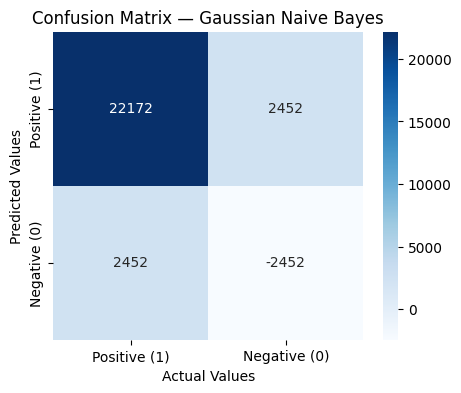

In [89]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Gaussian Naive Bayes predictions
cm = confusion_matrix(y_test, y_pred_nb)

# Calculate overall TP, FP, FN, TN
TP = np.trace(cm)
FP = cm.sum(axis=0).sum() - TP
FN = cm.sum(axis=1).sum() - TP
TN = cm.sum() - TP - FP - FN

# Create 2x2 confusion matrix
cm_nb = np.array([
    [TP, FP],
    [FN, TN]
])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Positive (1)', 'Negative (0)'],
    yticklabels=['Positive (1)', 'Negative (0)']
)

plt.title("Confusion Matrix — Gaussian Naive Bayes")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

9.4 Decision Tree

Decision Tree is a tree-based classification algorithm that recursively divides the feature space into branches based on feature values. The resulting decision rules are used to assign each observation to one of the attack categories.

The model is trained using the preprocessed training data and evaluated on the unseen testing data.

In [62]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model

dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model

dt_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_dt = dt_model.predict(X_test_scaled)

# Calculate evaluation metrics

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(
    y_test, y_pred_dt,
    average="weighted",
    zero_division=0
)
dt_recall = recall_score(
    y_test, y_pred_dt,
    average="weighted",
    zero_division=0
)
dt_f1 = f1_score(
    y_test, y_pred_dt,
    average="weighted",
    zero_division=0
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)

Decision Tree Results
---------------------
Accuracy : 0.9978882391163093
Precision: 0.9979032422970084
Recall   : 0.9978882391163093
F1-Score : 0.9978809385381039


In [63]:
print("Classification Report - Decision Tree")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - Decision Tree
                            precision    recall  f1-score   support

            ARP_poisioning       0.99      0.99      0.99      1550
            DDOS_Slowloris       0.99      1.00      1.00       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       0.78      1.00      0.88         7
             NMAP_FIN_SCAN       0.83      0.83      0.83         6
         NMAP_OS_DETECTION       1.00      1.00      1.00       400
             NMAP_TCP_scan       1.00      1.00      1.00       200
             NMAP_UDP_SCAN       0.99      1.00      0.99       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.99      0.99      0.99      1622
                Wipro_bulb       0.98      0.84      0.91        51

                  accuracy                           1.00     24624
        

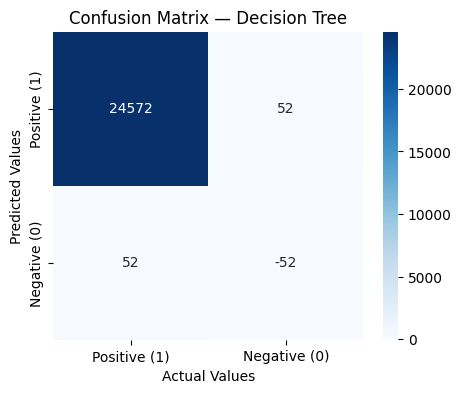

In [90]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Decision Tree predictions
cm = confusion_matrix(y_test, y_pred_dt)

# Calculate overall TP, FP, FN, TN
TP = np.trace(cm)
FP = cm.sum(axis=0).sum() - TP
FN = cm.sum(axis=1).sum() - TP
TN = cm.sum() - TP - FP - FN

# Create 2x2 confusion matrix
cm_dt = np.array([
    [TP, FP],
    [FN, TN]
])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Positive (1)', 'Negative (0)'],
    yticklabels=['Positive (1)', 'Negative (0)']
)

plt.title("Confusion Matrix — Decision Tree")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

9.5 Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised classification algorithm that identifies decision boundaries between classes by maximizing the separation between them.

For the multiclass problem, the SVM classifier uses a one-vs-one strategy internally to classify observations into the different attack categories.

The standardized feature matrix is used because SVM is sensitive to feature scale.

In [66]:
from sklearn.svm import SVC

# Create SVM model

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

# Train the model

svm_model.fit(X_train_scaled, y_train)

# Make predictions

y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate evaluation metrics

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(
    y_test, y_pred_svm,
    average="weighted",
    zero_division=0
)
svm_recall = recall_score(
    y_test, y_pred_svm,
    average="weighted",
    zero_division=0
)
svm_f1 = f1_score(
    y_test, y_pred_svm,
    average="weighted",
    zero_division=0
)

print("SVM Results")
print("------------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1-Score :", svm_f1)

SVM Results
------------
Accuracy : 0.9939896036387265
Precision: 0.9941350701540762
Recall   : 0.9939896036387265
F1-Score : 0.9938913032744667


In [67]:
print("Classification Report - SVM")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - SVM
                            precision    recall  f1-score   support

            ARP_poisioning       0.94      0.98      0.96      1550
            DDOS_Slowloris       1.00      0.80      0.89       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      0.99      0.99       829
Metasploit_Brute_Force_SSH       1.00      0.86      0.92         7
             NMAP_FIN_SCAN       0.62      0.83      0.71         6
         NMAP_OS_DETECTION       1.00      1.00      1.00       400
             NMAP_TCP_scan       1.00      1.00      1.00       200
             NMAP_UDP_SCAN       0.96      0.98      0.97       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.98      0.96      0.97      1622
                Wipro_bulb       0.97      0.61      0.75        51

                  accuracy                           0.99     24624
                 m

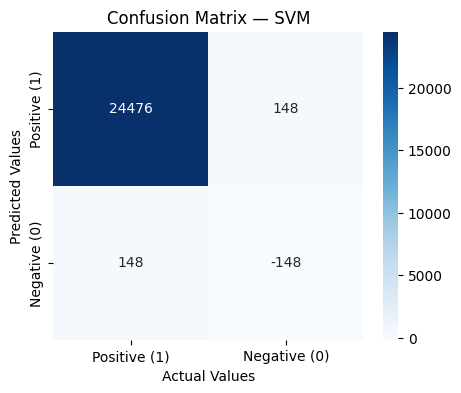

In [91]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# SVM predictions
cm = confusion_matrix(y_test, y_pred_svm)

# Calculate overall TP, FP, FN, TN
TP = np.trace(cm)
FP = cm.sum(axis=0).sum() - TP
FN = cm.sum(axis=1).sum() - TP
TN = cm.sum() - TP - FP - FN

# Create 2x2 confusion matrix
cm_svm = np.array([
    [TP, FP],
    [FN, TN]
])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Positive (1)', 'Negative (0)'],
    yticklabels=['Positive (1)', 'Negative (0)']
)

plt.title("Confusion Matrix — SVM")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

9.6 Hyperparameter Tuning

In [ ]:
 ### Logistic Regression Tuning

In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_tuned = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Hyperparameters to test
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# Grid Search
grid_lr = GridSearchCV(
    estimator=lr_tuned,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_lr.fit(X_train_scaled, y_train)

# Display results
print("Best Parameters:", grid_lr.best_params_)
print("Best Cross-Validation Accuracy:", grid_lr.best_score_)

Best Parameters: {'C': 100}
Best Cross-Validation Accuracy: 0.9929538117044091


In [ ]:
### KNN Hyperparameter Tuning

In [80]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_tuned = KNeighborsClassifier(
    metric='minkowski',
    p=2
)

# Hyperparameters to test
knn_param_grid = {
    'n_neighbors': [3, 5, 7]
}

# Grid Search
grid_knn = GridSearchCV(
    estimator=knn_tuned,
    param_grid=knn_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_knn.fit(X_train_scaled, y_train)

print("Best KNN Parameters:", grid_knn.best_params_)
print("Best KNN Cross-Validation Accuracy:", grid_knn.best_score_)

Best KNN Parameters: {'n_neighbors': 3}
Best KNN Cross-Validation Accuracy: 0.9961520108027981


 ### Gaussian Naive Bayes Tuning

In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

# Create Gaussian Naive Bayes model
nb_tuned = GaussianNB()

# Hyperparameters to test
nb_param_grid = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

# Grid Search
grid_nb = GridSearchCV(
    estimator=nb_tuned,
    param_grid=nb_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_nb.fit(X_train_scaled, y_train)

print("Best Gaussian Naive Bayes Parameters:", grid_nb.best_params_)
print("Best Gaussian Naive Bayes Cross-Validation Accuracy:", grid_nb.best_score_)

Best Gaussian Naive Bayes Parameters: {'var_smoothing': 1e-07}
Best Gaussian Naive Bayes Cross-Validation Accuracy: 0.9026225213974598


### Decision Tree Tuning

In [82]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_tuned = DecisionTreeClassifier(
    random_state=42
)

# Hyperparameters to test
dt_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5]
}

# Grid Search
grid_dt = GridSearchCV(
    estimator=dt_tuned,
    param_grid=dt_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_dt.fit(X_train_scaled, y_train)

print("Best Decision Tree Parameters:", grid_dt.best_params_)
print("Best Decision Tree Cross-Validation Accuracy:", grid_dt.best_score_)

Best Decision Tree Parameters: {'max_depth': 20, 'min_samples_split': 5}
Best Decision Tree Cross-Validation Accuracy: 0.9970556283187637


### SVM Tuning

In [84]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Create SVM model
svm_tuned = SVC(
    kernel='rbf',
    random_state=42
)

# Hyperparameters to test
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# Grid Search
grid_svm = GridSearchCV(
    estimator=svm_tuned,
    param_grid=svm_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_svm.fit(X_train_scaled, y_train)

print("Best SVM Parameters:", grid_svm.best_params_)
print("Best SVM Cross-Validation Accuracy:", grid_svm.best_score_)

Best SVM Parameters: {'C': 10, 'gamma': 'scale'}
Best SVM Cross-Validation Accuracy: 0.9947305899911668


9.7 Cross-Validation

In [75]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Gaussian Naive Bayes": nb_model,
    "Decision Tree": dt_model,
    "SVM": svm_model
}

cv_results = {}

for model_name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    cv_results[model_name] = scores
    
    print(f"{model_name}")
    print(f"Fold Accuracies: {scores}")
    print(f"Mean CV Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")
    print("-" * 50)

Logistic Regression
Fold Accuracies: [0.99157318 0.99147165 0.99116706 0.99248655 0.99121738]
Mean CV Accuracy: 0.9916
Standard Deviation: 0.0005
--------------------------------------------------
KNN
Fold Accuracies: [0.99538048 0.99598964 0.99517742 0.99644634 0.99644634]
Mean CV Accuracy: 0.9959
Standard Deviation: 0.0005
--------------------------------------------------
Gaussian Naive Bayes
Fold Accuracies: [0.89928423 0.8979136  0.89994416 0.9081125  0.90009138]
Mean CV Accuracy: 0.9011
Standard Deviation: 0.0036
--------------------------------------------------
Decision Tree
Fold Accuracies: [0.99725874 0.99710645 0.99659881 0.9980201  0.9978678 ]
Mean CV Accuracy: 0.9974
Standard Deviation: 0.0005
--------------------------------------------------
SVM
Fold Accuracies: [0.99253769 0.99350221 0.99243616 0.99390801 0.99294345]
Mean CV Accuracy: 0.9931
Standard Deviation: 0.0006
--------------------------------------------------


9.8 ROC-AUC Evaluation

Logistic Regression ROC-AUC: 0.9995
KNN ROC-AUC: 0.9995
Gaussian Naive Bayes ROC-AUC: 0.9966
Decision Tree ROC-AUC: 0.9989
SVM ROC-AUC: 0.9997


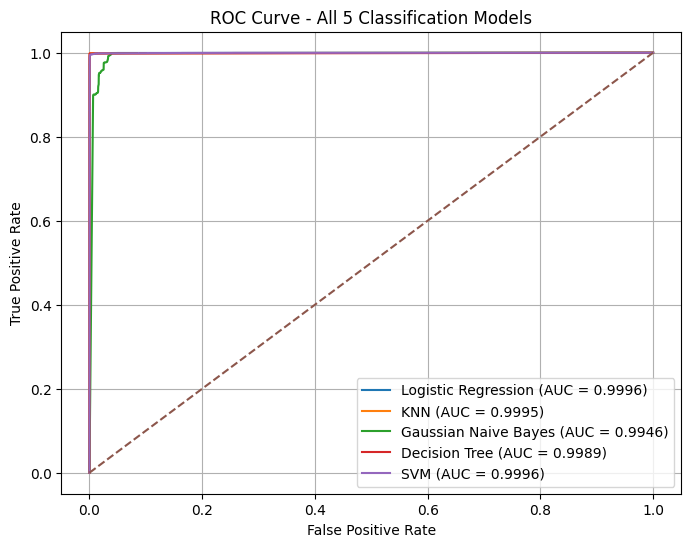

In [78]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

roc_auc_results = {}

# Convert actual labels to binary format
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

for model_name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)

        # Multiclass ROC-AUC
        roc_auc = roc_auc_score(
            y_test_bin,
            y_score,
            average='weighted',
            multi_class='ovr'
        )

    else:
        # For SVM: use decision scores
        y_score = model.decision_function(X_test_scaled)

        # Calculate one-vs-rest AUC for each class
        class_auc = []

        for i in range(len(classes)):
            auc = roc_auc_score(
                y_test_bin[:, i],
                y_score[:, i]
            )
            class_auc.append(auc)

        # Weighted average
        class_counts = np.bincount(y_test)
        weights = class_counts / class_counts.sum()

        roc_auc = np.average(class_auc, weights=weights)

    roc_auc_results[model_name] = roc_auc

    print(f"{model_name} ROC-AUC: {roc_auc:.4f}")
    from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Convert actual labels to binary format
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    # Get prediction scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_score = model.decision_function(X_test_scaled)

    # Micro-average ROC curve for multiclass classification
    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_score.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All 5 Classification Models")
plt.legend(loc="lower right")
plt.grid()
plt.show()

9.9 Model Tuning Improvement

In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Original model predictions
original_predictions = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Gaussian Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt,
    "SVM": y_pred_svm
}

# Tuned model predictions
tuned_predictions = {
    "Logistic Regression": grid_lr.best_estimator_.predict(X_test_scaled),
    "KNN": grid_knn.best_estimator_.predict(X_test_scaled),
    "Gaussian Naive Bayes": grid_nb.best_estimator_.predict(X_test_scaled),
    "Decision Tree": grid_dt.best_estimator_.predict(X_test_scaled),
    "SVM": grid_svm.best_estimator_.predict(X_test_scaled)
}

print("MODEL TUNING IMPROVEMENT")
print("=" * 80)

for model_name in original_predictions:

    original = original_predictions[model_name]
    tuned = tuned_predictions[model_name]

    # Before tuning
    before_accuracy = accuracy_score(y_test, original)
    before_precision = precision_score(
        y_test, original, average='weighted', zero_division=0
    )
    before_recall = recall_score(
        y_test, original, average='weighted', zero_division=0
    )
    before_f1 = f1_score(
        y_test, original, average='weighted', zero_division=0
    )

    # After tuning
    after_accuracy = accuracy_score(y_test, tuned)
    after_precision = precision_score(
        y_test, tuned, average='weighted', zero_division=0
    )
    after_recall = recall_score(
        y_test, tuned, average='weighted', zero_division=0
    )
    after_f1 = f1_score(
        y_test, tuned, average='weighted', zero_division=0
    )

    print(f"\n{model_name}")
    print("-" * 60)
    print(f"Accuracy  : Before = {before_accuracy:.4f} | After = {after_accuracy:.4f}")
    print(f"Precision : Before = {before_precision:.4f} | After = {after_precision:.4f}")
    print(f"Recall    : Before = {before_recall:.4f} | After = {after_recall:.4f}")
    print(f"F1-Score  : Before = {before_f1:.4f} | After = {after_f1:.4f}")
    print(f"Accuracy Improvement: {after_accuracy - before_accuracy:+.4f}")

MODEL TUNING IMPROVEMENT

Logistic Regression
------------------------------------------------------------
Accuracy  : Before = 0.9920 | After = 0.9929
Precision : Before = 0.9920 | After = 0.9929
Recall    : Before = 0.9920 | After = 0.9929
F1-Score  : Before = 0.9919 | After = 0.9928
Accuracy Improvement: +0.0009

KNN
------------------------------------------------------------
Accuracy  : Before = 0.9965 | After = 0.9968
Precision : Before = 0.9965 | After = 0.9968
Recall    : Before = 0.9965 | After = 0.9968
F1-Score  : Before = 0.9965 | After = 0.9968
Accuracy Improvement: +0.0002

Gaussian Naive Bayes
------------------------------------------------------------
Accuracy  : Before = 0.9004 | After = 0.9005
Precision : Before = 0.9636 | After = 0.9630
Recall    : Before = 0.9004 | After = 0.9005
F1-Score  : Before = 0.9088 | After = 0.9087
Accuracy Improvement: +0.0001

Decision Tree
------------------------------------------------------------
Accuracy  : Before = 0.9979 | After = 

9.10 Final Model Selection and Tuning

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Store tuned models
tuned_models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "KNN": grid_knn.best_estimator_,
    "Gaussian Naive Bayes": grid_nb.best_estimator_,
    "Decision Tree": grid_dt.best_estimator_,
    "SVM": grid_svm.best_estimator_
}

# Store cross-validation scores from tuning
cv_scores = {
    "Logistic Regression": grid_lr.best_score_,
    "KNN": grid_knn.best_score_,
    "Gaussian Naive Bayes": grid_nb.best_score_,
    "Decision Tree": grid_dt.best_score_,
    "SVM": grid_svm.best_score_
}

# Calculate final test-set metrics
final_results = []

for model_name, model in tuned_models.items():

    predictions = model.predict(X_test_scaled)

    final_results.append({
        "Model": model_name,
        "CV Accuracy": cv_scores[model_name],
        "Test Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, average='weighted', zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, average='weighted', zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, predictions, average='weighted', zero_division=0
        )
    })

# Create comparison table
final_results_df = pd.DataFrame(final_results)

print("FINAL TUNED MODEL COMPARISON")
print("=" * 80)

display(
    final_results_df.style.format({
        "CV Accuracy": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

# Select final model based on cross-validation accuracy
best_model_name = final_results_df.loc[
    final_results_df["CV Accuracy"].idxmax(),
    "Model"
]

print("\nFinal Selected Model:", best_model_name)
print("Reason: Highest cross-validation accuracy among the tuned models.")
print("Best Parameters:", tuned_models[best_model_name].get_params())

FINAL TUNED MODEL COMPARISON


,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9930,0.9929,0.9929,0.9929,0.9928
1,KNN,0.9962,0.9968,0.9968,0.9968,0.9968
2,Gaussian Naive Bayes,0.9026,0.9005,0.9630,0.9005,0.9087
3,Decision Tree,0.9971,0.9976,0.9976,0.9976,0.9976
4,SVM,0.9947,0.9952,0.9953,0.9952,0.9952



Final Selected Model: Decision Tree
Reason: Highest cross-validation accuracy among the tuned models.
Best Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


10. Model Performance Comparison

The performance of all five classification algorithms is compared using Accuracy, Precision, Recall, and F1-Score. These metrics provide an overall comparison of the classification performance across the twelve attack categories.

In [71]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        nb_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        knn_precision,
        nb_precision,
        dt_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        knn_recall,
        nb_recall,
        dt_recall,
        svm_recall
    ],
    "F1-Score": [
        lr_f1,
        knn_f1,
        nb_f1,
        dt_f1,
        svm_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.992040,0.991987,0.992040,0.991923
1,KNN,0.996507,0.996513,0.996507,0.996497
2,Gaussian Naive Bayes,0.900422,0.963624,0.900422,0.908829
3,Decision Tree,0.997888,0.997903,0.997888,0.997881
4,SVM,0.993990,0.994135,0.993990,0.993891


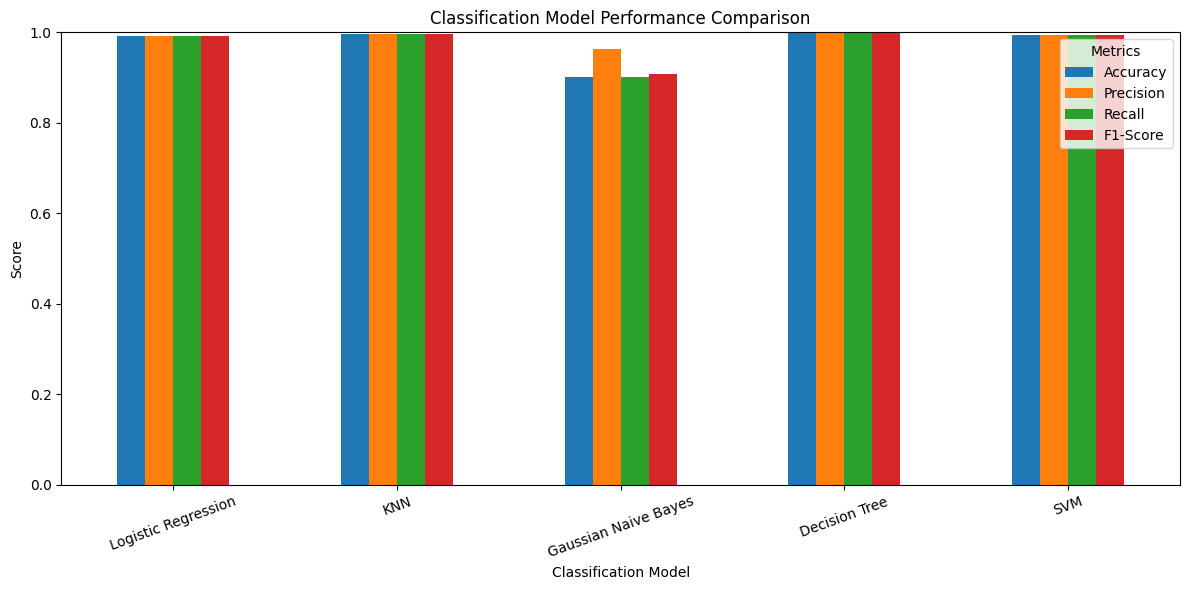

In [72]:
# Plot model performance comparison

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

10.1 Observation

The five classification algorithms show high overall performance on the network traffic classification dataset.

Logistic Regression, KNN, Decision Tree, and SVM achieve high Accuracy, Precision, Recall, and F1-Score values, indicating that the models are able to classify the different attack categories effectively.

Gaussian Naive Bayes shows comparatively lower performance than the other four models, particularly in Recall and F1-Score. This indicates that its probabilistic assumptions are less suitable for some of the network traffic patterns in the dataset.

The results demonstrate that the choice of classification algorithm affects the ability to distinguish between the different attack categories.

10.2 Class-wise Performance Analysis

The class-wise TP, TN, FP, and FN values obtained from the five classification models are examined to understand how each model performs across the individual attack categories.

These values provide a detailed view of correct classifications, missed attack instances, and incorrect classifications for each class.

In [73]:
# Combine class-wise TP, TN, FP and FN values from all five models

classwise_comparison = pd.DataFrame({
    "Class": label_encoder.classes_,
    
    "LR_TP": class_metrics_df["TP"].values,
    "LR_TN": class_metrics_df["TN"].values,
    "LR_FP": class_metrics_df["FP"].values,
    "LR_FN": class_metrics_df["FN"].values,
    
    "KNN_TP": knn_class_metrics_df["TP"].values,
    "KNN_TN": knn_class_metrics_df["TN"].values,
    "KNN_FP": knn_class_metrics_df["FP"].values,
    "KNN_FN": knn_class_metrics_df["FN"].values,
    
    "NB_TP": nb_class_metrics_df["TP"].values,
    "NB_TN": nb_class_metrics_df["TN"].values,
    "NB_FP": nb_class_metrics_df["FP"].values,
    "NB_FN": nb_class_metrics_df["FN"].values,
    
    "DT_TP": dt_class_metrics_df["TP"].values,
    "DT_TN": dt_class_metrics_df["TN"].values,
    "DT_FP": dt_class_metrics_df["FP"].values,
    "DT_FN": dt_class_metrics_df["FN"].values,
    
    "SVM_TP": svm_class_metrics_df["TP"].values,
    "SVM_TN": svm_class_metrics_df["TN"].values,
    "SVM_FP": svm_class_metrics_df["FP"].values,
    "SVM_FN": svm_class_metrics_df["FN"].values
})

classwise_comparison

,Class,LR_TP,LR_TN,LR_FP,LR_FN,KNN_TP,KNN_TN,KNN_FP,KNN_FN,NB_TP,...,NB_FP,NB_FN,DT_TP,DT_TN,DT_FP,DT_FN,SVM_TP,SVM_TN,SVM_FP,SVM_FN
0,ARP_poisioning,1470,23002,72,80,1525,23029,45,25,565,...,16,985,1533,23056,18,17,1526,22985,89,24
1,DDOS_Slowloris,86,24513,4,21,102,24513,4,5,105,...,501,2,107,24516,1,0,86,24517,0,21
2,DOS_SYN_Hping,18932,5692,0,0,18932,5692,0,0,18932,...,0,0,18932,5692,0,0,18932,5692,0,0
3,MQTT_Publish,827,23795,0,2,826,23794,1,3,825,...,0,4,827,23794,1,2,820,23795,0,9
4,Metasploit_Brute_Force_SSH,6,24617,0,1,6,24617,0,1,7,...,596,0,7,24615,2,0,6,24617,0,1
5,NMAP_FIN_SCAN,5,24617,1,1,5,24617,1,1,5,...,773,1,5,24617,1,1,5,24615,3,1
6,NMAP_OS_DETECTION,400,24221,3,0,400,24221,3,0,400,...,0,0,400,24224,0,0,400,24223,1,0
7,NMAP_TCP_scan,200,24423,1,0,200,24424,0,0,200,...,1,0,200,24424,0,0,200,24423,1,0
8,NMAP_UDP_SCAN,509,24084,22,9,512,24099,7,6,473,...,429,45,516,24099,7,2,509,24086,20,9
9,NMAP_XMAS_TREE_SCAN,400,24222,0,2,400,24222,0,2,400,...,0,2,400,24221,1,2,400,24222,0,2


10.3 Overall Classification Results

The overall performance of the five classification algorithms is summarized using Accuracy, Precision, Recall, and F1-Score. These metrics provide a consolidated view of the classification performance across all attack categories.

In [74]:
# Display the overall model comparison

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9920,0.9920,0.9920,0.9919
1,KNN,0.9965,0.9965,0.9965,0.9965
2,Gaussian Naive Bayes,0.9004,0.9636,0.9004,0.9088
3,Decision Tree,0.9979,0.9979,0.9979,0.9979
4,SVM,0.9940,0.9941,0.9940,0.9939


10.4 Overall Observation

The experimental results show that the five classification algorithms achieve high performance on the network traffic attack classification task.

The models differ in their Accuracy, Precision, Recall, and F1-Score values, indicating differences in how effectively they identify the twelve attack categories.

The class-wise TP, TN, FP, and FN analysis further provides detailed information about correct and incorrect classifications for each attack category.

Overall, the comparison demonstrates that classification performance depends on the underlying learning approach and the characteristics of the network traffic data.